# Analysis - Availability Windows
Analysing the output from the Availability Window Experiments.

## Load Libraries

In [1]:
import pandas as pd
import pickle
import json
import os
import datetime as dt
from matplotlib import pyplot as plt
import re
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
from pandas.api.types import CategoricalDtype

## Load Data

In [2]:
vwt_out = "D:/lco/custom_scheduler/output_files/vwt"
vwt_in = "D:/lco/custom_scheduler/input_files/vwt"
baseline_out = "D:/lco/custom_scheduler/output_files/baseline"
print(os.path.isdir(vwt_out))
print(os.path.isdir(vwt_in))
print(os.path.isdir(baseline_out))

True
True
True


In [3]:
filemap = {}
for dirname, folders, filenames in os.walk(vwt_in):
    for filename in filenames:
        output_filepath = os.path.join(vwt_out, filename)
        forename, ext = os.path.splitext(filename)
        perfect_filepath = os.path.join(vwt_out, forename + "_perfect" + ext)
        baseline_filepath = os.path.join(baseline_out, forename.replace("vwt_", "baseline_")+ext)
        print(filename)
        print(os.path.isfile(output_filepath), output_filepath)
        print(os.path.isfile(perfect_filepath), perfect_filepath)
        print(os.path.isfile(baseline_filepath), baseline_filepath)
        filemap[filename] = {
            "input": os.path.join(dirname, filename),
            "output": output_filepath,
            "perfect": perfect_filepath,
            "baseline": baseline_filepath
        }

vwt_2020-08.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2020-08.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2020-08_perfect.pkl
True D:/lco/custom_scheduler/output_files/baseline\baseline_2020-08.pkl
vwt_2021-02.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2021-02.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2021-02_perfect.pkl
True D:/lco/custom_scheduler/output_files/baseline\baseline_2021-02.pkl
vwt_2021-08.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2021-08.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2021-08_perfect.pkl
True D:/lco/custom_scheduler/output_files/baseline\baseline_2021-08.pkl
vwt_2022-02.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2022-02.pkl
True D:/lco/custom_scheduler/output_files/vwt\vwt_2022-02_perfect.pkl
True D:/lco/custom_scheduler/output_files/baseline\baseline_2022-02.pkl


In [4]:
calib_proposals = [
    "OGG_calib",
    "MuSCAT Commissioning",
    "auto_focus",
    "LCOEngineering",
    "COJ_calib",
    "FLOYDS standards",
    "Photometric standards",
    "standard"
]

In [5]:
df_results = pd.DataFrame()
df_requests = pd.DataFrame()
proposals = {}

for filename in filemap:
    i = pickle.load(open(filemap[filename]["input"], "rb")) #input
    o = pickle.load(open(filemap[filename]["output"], "rb")) #output
    p = pickle.load(open(filemap[filename]["perfect"], "rb")) #perfect
    b = pickle.load(open(filemap[filename]["baseline"], "rb")) #baseline

    # proposals = i["proposals"]
    # for calib_name in calib_proposals:
    #     if calib_name in proposals:
    #         proposals[calib_name] = 0

    data = i["all_requests"][["id", "new_window_length"]]
    data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
    data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
    data["perfect"] = data["id"].isin(p["scheduled"].keys())
            
    print("FILENAME:", filename)
    for availability, group in data.groupby("new_window_length"):
        print("Availability Length:", availability)
        print("Num Requests:", len(group))
        print("Baseline:", group["baseline"].sum(), f"({round(group['baseline'].sum()/len(group)*100, 2)}%)")
        print("Scheduled:", group["scheduled"].sum(), f"({round(group['scheduled'].sum()/len(group)*100, 2)}%)")
        print("Perfect:", group["perfect"].sum(), f"({round(group['perfect'].sum()/len(group)*100, 2)}%)")
        print()
    print("===\n\n")

    df_results = pd.concat([df_results, data])
    df_requests = pd.concat([df_requests, i["all_requests"]])
    proposals.update(i["proposals"])
    
    # data["filename"] = filename

    # datasets[filename] = data
df_proposals = pd.Series({k:v for k,v in proposals.items() if k not in calib_proposals})
df_proposals = pd.DataFrame(df_proposals).reset_index().rename(columns={"index": "proposal_id", 0: "tac_priority"})

C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

FILENAME: vwt_2020-08.pkl
Availability Length: 1.0
Num Requests: 1828
Baseline: 1446 (79.1%)
Scheduled: 1359 (74.34%)
Perfect: 1276 (69.8%)

Availability Length: 3.0
Num Requests: 1830
Baseline: 1462 (79.89%)
Scheduled: 1416 (77.38%)
Perfect: 1344 (73.44%)

Availability Length: 7.0
Num Requests: 1830
Baseline: 1448 (79.13%)
Scheduled: 1445 (78.96%)
Perfect: 1382 (75.52%)

Availability Length: 28.0
Num Requests: 459
Baseline: 354 (77.12%)
Scheduled: 365 (79.52%)
Perfect: 363 (79.08%)

===




C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

FILENAME: vwt_2021-02.pkl
Availability Length: 1.0
Num Requests: 4008
Baseline: 1738 (43.36%)
Scheduled: 1311 (32.71%)
Perfect: 1032 (25.75%)

Availability Length: 3.0
Num Requests: 4010
Baseline: 1704 (42.49%)
Scheduled: 1604 (40.0%)
Perfect: 1208 (30.12%)

Availability Length: 7.0
Num Requests: 4009
Baseline: 1720 (42.9%)
Scheduled: 1784 (44.5%)
Perfect: 1333 (33.25%)

Availability Length: 28.0
Num Requests: 1004
Baseline: 441 (43.92%)
Scheduled: 532 (52.99%)
Perfect: 430 (42.83%)

===




C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

FILENAME: vwt_2021-08.pkl
Availability Length: 1.0
Num Requests: 2567
Baseline: 1979 (77.09%)
Scheduled: 1875 (73.04%)
Perfect: 1601 (62.37%)

Availability Length: 3.0
Num Requests: 2569
Baseline: 1952 (75.98%)
Scheduled: 1959 (76.26%)
Perfect: 1678 (65.32%)

Availability Length: 7.0
Num Requests: 2569
Baseline: 1933 (75.24%)
Scheduled: 2023 (78.75%)
Perfect: 1864 (72.56%)

Availability Length: 28.0
Num Requests: 644
Baseline: 480 (74.53%)
Scheduled: 534 (82.92%)
Perfect: 500 (77.64%)

===


FILENAME: vwt_2022-02.pkl
Availability Length: 1.0
Num Requests: 2607
Baseline: 2015 (77.29%)
Scheduled: 1889 (72.46%)
Perfect: 1511 (57.96%)

Availability Length: 3.0
Num Requests: 2609
Baseline: 2018 (77.35%)
Scheduled: 2013 (77.16%)
Perfect: 1634 (62.63%)

Availability Length: 7.0
Num Requests: 2609
Baseline: 2025 (77.62%)
Scheduled: 2100 (80.49%)
Perfect: 1727 (66.19%)

Availability Length: 28.0
Num Requests: 653
Baseline: 487 (74.58%)
Scheduled: 533 (81.62%)
Perfect: 478 (73.2%)

===




C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\2873119394.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

## Extract Relevant Values

In [6]:
def get_visible_duration(windows):
    total_time = dt.timedelta()
    for site_code, intervals in windows.items():
        interval_time = intervals.get_total_time()
        if interval_time != 0:
            total_time += interval_time
    return total_time.total_seconds()

def get_availability_duration(availability_windows):
    time = dt.timedelta()
    for window in availability_windows:
        try:
            start = dt.datetime.strptime(window["start"], "%Y-%m-%dT%H:%M:%S.%fZ")
        except ValueError:
            start = dt.datetime.strptime(window["start"], "%Y-%m-%dT%H:%M:%SZ")

        try:
            end = dt.datetime.strptime(window["end"], "%Y-%m-%dT%H:%M:%S.%fZ")
        except ValueError:
            end = dt.datetime.strptime(window["end"], "%Y-%m-%dT%H:%M:%SZ")
        
        time += end - start
    return time.total_seconds()

In [7]:
temp = df_requests.merge(df_proposals, how="left", on="proposal_id")
temp["old_visible_time"] = temp["visibilities"].apply(get_visible_duration)
temp["new_visible_time"] = temp["windows"].apply(get_visible_duration)

temp["old_availability"] = temp["availability_windows"].apply(get_availability_duration)
temp["new_availability"] = temp["new_window_length"] * 60 * 60 * 24

temp["old_flexibility"] = temp["old_visible_time"] / temp["total_duration"]
temp["new_flexibility"] = temp["new_visible_time"] / temp["total_duration"]

df_info = temp[["id", "total_duration", "tac_priority", "new_flexibility", "old_flexibility"]]

## Combine Data

In [8]:
df = df_results.merge(df_info, how="left", on="id")
# Remove Calibration Requests
df = df[df["new_window_length"].notna()]
df

,id,new_window_length,scheduled,baseline,perfect,total_duration,tac_priority,new_flexibility,old_flexibility
0,2373081,3.0,False,False,False,3088,16.0,32.105169,10.848893
1,2373019,7.0,True,True,True,19422,30.0,14.169495,1.004016
2,2373018,7.0,False,False,False,3388,16.0,20.219894,3.464724
3,2373014,1.0,False,False,False,3388,16.0,9.264349,9.53541
10,2372981,1.0,False,False,False,499,20.0,3.607214,3.607214
...,...,...,...,...,...,...,...,...,...
49001,2858916,7.0,True,False,False,360,20.0,223.133003,249.311843
49013,2858847,1.0,True,True,True,2445,35.0,9.47049,9.470491
49014,2858588,1.0,True,True,True,2745,35.0,12.86091,12.860911
49015,2858587,1.0,False,False,False,1480,20.0,9.335374,66.270702


## Get Pos and Neg Changes

In [9]:
df["change_positive"] = ((df["scheduled"]==True) & (df["baseline"]==False)).astype(int)
df["change_negative"] = -1*((df["scheduled"]==False) & (df["baseline"]==True)).astype(int)
df["change"] = df["scheduled"].astype(int) - df["baseline"].astype(int)
df

,id,new_window_length,scheduled,baseline,perfect,total_duration,tac_priority,new_flexibility,old_flexibility,change_positive,change_negative,change
0,2373081,3.0,False,False,False,3088,16.0,32.105169,10.848893,0,0,0
1,2373019,7.0,True,True,True,19422,30.0,14.169495,1.004016,0,0,0
2,2373018,7.0,False,False,False,3388,16.0,20.219894,3.464724,0,0,0
3,2373014,1.0,False,False,False,3388,16.0,9.264349,9.53541,0,0,0
10,2372981,1.0,False,False,False,499,20.0,3.607214,3.607214,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
49001,2858916,7.0,True,False,False,360,20.0,223.133003,249.311843,1,0,1
49013,2858847,1.0,True,True,True,2445,35.0,9.47049,9.470491,0,0,0
49014,2858588,1.0,True,True,True,2745,35.0,12.86091,12.860911,0,0,0
49015,2858587,1.0,False,False,False,1480,20.0,9.335374,66.270702,0,0,0


# Running Chi-Squared on Subsets
You can run separate Chi-squared tests for different subsets of the data. This is useful if you suspect that the relationship between new_window_length and success_change might vary across different groups (e.g., by proposal priority, request duration, etc.). You would manually split your dataset based on these additional variables and run the Chi-squared test on each subset.

In [10]:
def set_duration_category(total_duration):
    if total_duration <= 600:
        return "Short"
    elif total_duration <= 1800:
        return "Medium"
    else:
        return "Long"

duration_type = CategoricalDtype(categories=["Long", "Medium", "Short"], ordered=True)

df["total_duration_category"] = df["total_duration"].apply(set_duration_category).astype(duration_type)

In [11]:
def set_priority_category(tac_priority):
    if tac_priority <= 15:
        return "Low"
    elif tac_priority <= 29:
        return "Intermediate"
    else:
        return "High"

priority_type = CategoricalDtype(categories=["Low", "Intermediate", "High"], ordered=True)

df["tac_priority_category"] = df["tac_priority"].apply(set_priority_category).astype(priority_type)

## All Change

In [13]:
# a

In [14]:
# b

C:\Users\Foggy\AppData\Local\Temp\ipykernel_16520\417867583.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):


('Long', 'Low')
Chi2: 2.458853278988769, P-value: 0.8730439185713621, Degrees of Freedom: 6
new_window_length
1.0    -0.079755
3.0    -0.085714
7.0    -0.076923
28.0   -0.083333
dtype: float64
507
-1 70
0 408
1 29

('Long', 'Intermediate')
Chi2: 24.558704382726454, P-value: 0.00041202610801437947, Degrees of Freedom: 6
new_window_length
1.0    -0.020039
3.0     0.000643
7.0     0.013514
28.0    0.048711
dtype: float64
4931
-1 599
0 3726
1 606

('Long', 'High')
Chi2: 59.77320507577619, P-value: 5.0047077685150836e-11, Degrees of Freedom: 6
new_window_length
1.0    -0.024498
3.0     0.030315
7.0     0.052591
28.0    0.042748
dtype: float64
8219
-1 696
0 6649
1 874

('Medium', 'Low')
Chi2: 7.250455120448504, P-value: 0.29830513037666373, Degrees of Freedom: 6
new_window_length
1.0    -0.208955
3.0    -0.124464
7.0    -0.136364
28.0   -0.107143
dtype: float64
710
-1 135
0 547
1 28

('Medium', 'Intermediate')
Chi2: 20.333524992039074, P-value: 0.00241504168282792, Degrees of Freedom: 6
new_

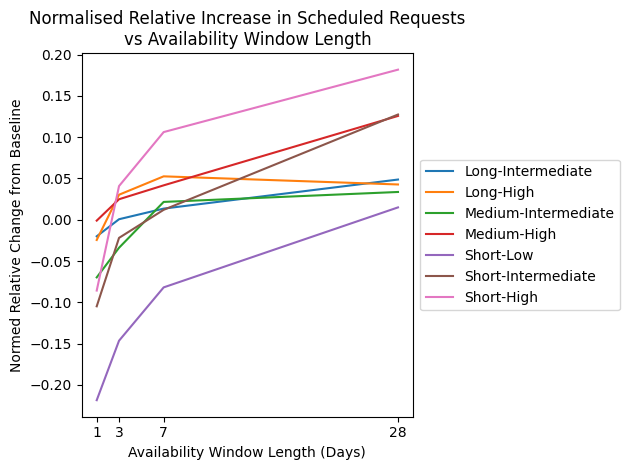

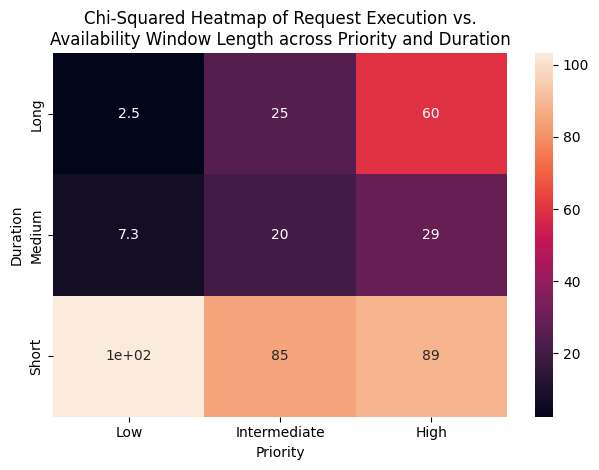

In [15]:
chi_all = []
stats_all = []

for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
    contingency_table = pd.crosstab(group["new_window_length"], group["change"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(values)
    print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")

    a = contingency_table
    b = a.div(a.sum(axis=1), axis=0)
    c = b.apply(lambda x: x[-1]*-1 + x[1], axis=1)
    print(c)    
    # print(contingency_table.apply(lambda x: x[-1]*-1 + x[1], axis=1))

    if chi2 > 10:
        ax = sns.lineplot(c, label="-".join(values))
    
    print(len(group))
    for cval, g2 in group.groupby("change"):
        print(cval, len(g2))
    
    print()
    chi_all.append([*values, chi2, p])

    pp = sum((group["baseline"])&(group["scheduled"]))
    pn = sum((group["baseline"])&(~group["scheduled"]))
    np = sum((~group["baseline"])&(group["scheduled"]))
    nn = sum((~group["baseline"])&(~group["scheduled"]))

    stats_all.append([pp, nn, pn, np])

# Adjust Legend for Lineplots
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Normalised Relative Increase in Scheduled Requests\nvs Availability Window Length")
# ax.set_title("Relative Change from Baseline in Number of Requests Executed, for 
ax.set_xlabel("Availability Window Length (Days)")
ax.set_ylabel("Normed Relative Change from Baseline")
ax.set_xticks([1, 3, 7, 28])
# plt.xscale("log")
plt.tight_layout()
plt.savefig("plots/vwt_lineplot.pdf", format="pdf")
plt.show()

chi_df = pd.DataFrame(chi_all, columns=["Duration", "Priority", "Chi2", "P-Value"])
chi_df["Duration"] = chi_df["Duration"].astype(duration_type)
chi_df["Priority"] = chi_df["Priority"].astype(priority_type)
chi_df_plot = chi_df.pivot(index="Duration", columns="Priority", values="Chi2")
ax = sns.heatmap(chi_df_plot, annot=True)

# plt.title("Chi-Squared Score for Availability Window Length against Relative Requests Executed")

plt.title("Chi-Squared Heatmap of Request Execution vs.\nAvailability Window Length across Priority and Duration")
plt.tight_layout()
plt.savefig("plots/vwt_chi2.pdf", format="pdf")
plt.show()
# for x in stats_all:
#     print(x)

In [ ]:
# chi_all = []
# stats_all = []

# for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
#     contingency_table = pd.crosstab(group["new_window_length"], group["change"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
#     print(values)
#     print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")

#     print(len(group))
#     for cval, g2 in group.groupby("change"):
#         print(cval, len(g2))
    
#     print()
#     chi_all.append([*values, chi2, p])

#     pp = sum((group["baseline"])&(group["scheduled"]))
#     pn = sum((group["baseline"])&(~group["scheduled"]))
#     np = sum((~group["baseline"])&(group["scheduled"]))
#     nn = sum((~group["baseline"])&(~group["scheduled"]))

#     stats_all.append([pp, nn, pn, np])

#     # print("     ", "[", "S", "|", "~S", "]")
#     # print("Base ", "[", pp, "|", pn, "]")
#     # print("~Base", "[", np, "|", nn, "]")
    
#     # print(group[["baseline", "scheduled"]].value_counts())

# chi_df = pd.DataFrame(chi_all, columns=["Duration", "Priority", "Chi2", "P-Value"])
# chi_df_plot = chi_df.pivot(index="Duration", columns="Priority", values="Chi2")

# ax = sns.heatmap(chi_df_plot, annot=False)
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

# # # Iterate over the data to place custom annotations
# # for i in range(chi_df.shape[0]):  # rows
# #     for j in range(chi_df.shape[1]):  # columns
# #         value = df.iloc[i, j]
# #         text = "hello"  # Get the additional info
# #         ax.text(j + 0.5, i + 0.5, f'{value}\n{text}', 
# #                 ha='center', va='center', color='white')

# # Get the heatmap values
# heatmap_values = ax.collections[0].get_array().reshape(chi_df_plot.shape)

# # Get the color map
# cmap = ax.collections[0].cmap
# norm = ax.collections[0].norm  # Normalize function

# # Iterate over the data to place custom annotations with color-based text
# for i in range(chi_df_plot.shape[0]):  # rows
#     for j in range(chi_df_plot.shape[1]):  # columns
#         value = chi_df_plot.iloc[i, j]

#         print(i, j)
        
#         # Get the background color for the current cell
#         cell_value = heatmap_values[i, j]
#         color = cmap(norm(cell_value))
        
#         # Calculate the brightness of the color to determine the text color
#         brightness = (color[0] * 299 + color[1] * 587 + color[2] * 114) / 1000
        
#         text_color = 'black' if brightness > 0.5 else 'white'

#         text_val = "Hello"
        
#         # Add text with appropriate color
#         ax.text(j + 0.5, i + 0.5, f'{round(value,1)}\n{text_val}', 
#                 ha='center', va='center', color=text_color)

# for x in stats_all:
#     print(x)

## Positive Change

In [ ]:
# chi_pos = []

# for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
#     contingency_table = pd.crosstab(group["new_window_length"], group["change_positive"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
#     print(values)
#     print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")
#     print()
#     chi_pos.append([*values, chi2, p])

# chi_df_pos = pd.DataFrame(chi_pos, columns=["Duration", "Priority", "Chi2", "P-Value"])
# sns.heatmap(chi_df_pos.pivot(index="Duration", columns="Priority", values="Chi2"), annot=True)
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

## Negative Change

In [ ]:
# df["change"].value_counts()

In [ ]:
# chi_neg = []

# for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
#     contingency_table = pd.crosstab(group["new_window_length"], group["change_negative"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
#     print(values)
#     print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")
#     print()
#     chi_neg.append([*values, chi2, p])

# chi_df_neg = pd.DataFrame(chi_neg, columns=["Duration", "Priority", "Chi2", "P-Value"])
# sns.heatmap(chi_df_neg.pivot(index="Duration", columns="Priority", values="Chi2"), annot=True)
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

# Analysis - UNUSED

### Logistic Regression

In [ ]:
# df

In [ ]:
# # for colname in df.columns:
#     # if colname != "id":
#     #     df[colname] = pd.to_numeric(df[colname])
# df["change_positive"] = ((df["scheduled"]==True) & (df["baseline"]==False)).astype(int)
# df["change_negative"] = ((df["scheduled"]==False) & (df["baseline"]==True)).astype(int)
# df

In [ ]:
# # Assume window_length is continuous
# X = df[['new_window_length', 'total_duration', 'tac_priority', 'new_flexibility', 'old_flexibility']]
# y = df['change_positive']

# # Add constant
# X = sm.add_constant(X)

# # Fit logistic regression model
# model = sm.Logit(y, X)
# result = model.fit()

# print(result.summary())

# UNUSED

In [ ]:
# # Assume window_length is continuous
# X = df[['new_window_length', 'total_duration', 'tac_priority', 'new_flexibility', 'old_flexibility']]
# y = df['change_negative']

# # Add constant
# X = sm.add_constant(X)

# # Fit logistic regression model
# model = sm.Logit(y, X)
# result = model.fit()

# print(result.summary())

In [ ]:
# sns.pairplot(df[['new_window_length', 'tac_priority', 'total_duration', 'new_flexibility', 'success_change']], hue='success_change')

### Chi2 Test

In [ ]:
# # Create a contingency table
# contingency_table = pd.crosstab(df['new_window_length'], df['success_change'])
# print(contingency_table)

# # Perform Chi-Square test
# chi2, p, dof, expected = chi2_contingency(contingency_table)

# # Output the results
# print(f"Chi-Square Statistic: {chi2}")
# print(f"P-value: {p}")
# print(f"Degrees of Freedom: {dof}")
# print("Expected Frequencies:")
# print(expected)

### Multi-Nomial Logistic Regression

In [ ]:
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# # Define your predictor variables
# X = df[['new_window_length', 'tac_priority', 'total_duration', 'new_flexibility']]

# # Standardize the continuous variables (optional but often helpful)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Add a constant (intercept term)
# X_scaled = sm.add_constant(X_scaled)

# # Define your response variable (multiclass)
# y = df['success_change']

# # Fit a multinomial logistic regression model
# model = sm.MNLogit(y, X_scaled)
# result = model.fit()

# # View the summary of the model
# print(result.summary())


#### MN Logistic Regression with Interaction Terms

In [ ]:
# # Create a formula with interaction terms
# formula = 'success_change ~ new_window_length * total_duration + tac_priority * new_flexibility'

# # Fit the logistic regression model with interaction terms
# model = sm.MNLogit.from_formula(formula, df)
# result = model.fit()

# # View the model summary
# print(result.summary())

### Generalized Linear Model (GLM)
If you want to stay within the realm of chi-squared-like models, you can use a Generalized Linear Model (GLM) with a multinomial outcome (similar to multinomial logistic regression). This allows you to include multiple variables while extending the chi-squared test framework.

In [ ]:
# from statsmodels.genmod.generalized_linear_model import GLM
# from statsmodels.genmod.families import Binomial

# # Fit a GLM model
# glm_model = GLM(df['success_change'], X_scaled, family=sm.families.Binomial())
# glm_result = glm_model.fit()

# # View the summary
# print(glm_result.summary())

### Cross-Tabulation
Another option is to create a cross-tabulation (contingency table) that includes multiple categorical variables. This approach is a multivariate extension of Chi-squared testing, and while it doesn't allow for continuous variables, it can give you a sense of how multiple categorical variables jointly affect the outcome.

Need to convert data into purely categorical variables first.

In [ ]:
# from scipy import stats

# # Cross-tabulate new_window_length, tac_priority, and success_change
# contingency_table = pd.crosstab([df['new_window_length'], df['tac_priority']], df['success_change'])

# # Perform the Chi-squared test on this multi-dimensional table
# chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")


## Logistic Regression with Interaction Terms

In [ ]:
# # Assuming 'df' is your DataFrame with 'success_change', 'new_window_length', and 'tac_priority'
# df['interaction_term'] = df['new_window_length'] * df['tac_priority']

# # Add a constant for intercept
# X = df[['new_window_length', 'tac_priority', 'interaction_term', 'total_duration']]
# X = sm.add_constant(X)

# # Logistic regression with interaction term
# model = sm.MNLogit(df['success_change'], X)
# result = model.fit()

# # View the results
# print(result.summary())

In [ ]:
# import xgboost as xgb

## XGBoost

In [ ]:
# df.columns

In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import random

# # Assuming you have a DataFrame df with independent variables 'Priority', 'Duration', 'Flexibility', 'Lead_In' and dependent variable 'Success'

# df["random"] = [random.random() for x in range(len(df))]
# df["change"] = df["scheduled"] != df["baseline"]

# # Prepare independent (X) and dependent (y) variables
# X = df[["tac_priority", "total_duration", "new_window_length", "baseline", "random"]].astype(float)
# y = df['change'].astype(float)
# # X = df[['Priority', 'Duration', 'Flexibility', 'Lead_In']]  # Independent variables
# # y = df['Success']  # Dependent variable (binary outcome)

# # Split data into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Create a DMatrix for XGBoost
# train_dmatrix = xgb.DMatrix(X_train, label=y_train)
# test_dmatrix = xgb.DMatrix(X_test, label=y_test)

# # Set parameters for XGBoost
# params = {
#     'objective': 'reg:logistic',  # Logistic regression for binary classification
#     'eval_metric': 'logloss',
#     'max_depth': 3,  # Depth of trees
#     'learning_rate': 0.1,
#     'n_estimators': 500
# }

# # Train the XGBoost model
# xgb_model = xgb.train(params, train_dmatrix, num_boost_round=100)

# # Predict on the test set
# y_pred = xgb_model.predict(test_dmatrix)
# y_pred = [1 if pred > 0.5 else 0 for pred in y_pred]  # Convert probabilities to 0/1

# # Evaluate accuracy
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy}")

In [ ]:
# xgb.plot_importance(xgb_model)

In [ ]:
# df["random"]

### Help

In [ ]:
# import statsmodels.api as sm
# import pandas as pd

# # Assuming df is your dataframe with the relevant columns

# # Create interaction terms
# df['interaction_tac_priority'] = df['new_window_length'] * df['tac_priority']
# df['interaction_total_duration'] = df['new_window_length'] * df['total_duration']

# # Optionally: Create quadratic terms if you suspect non-linearity
# df['tac_priority_squared'] = df['tac_priority'] ** 2
# df['total_duration_squared'] = df['total_duration'] ** 2

# # Create three-way interaction term
# df['three_way_interaction'] = df['new_window_length'] * df['tac_priority'] * df['total_duration']

# # Create scheduled_positive variable (if request is scheduled when it was not in the baseline)
# df["success_change"] = (df["scheduled"] == True) & (df["baseline"]==False)

# # Fit a logistic regression model with interaction terms and quadratic terms
# df['intercept'] = 1  # Add a constant

# # Define independent variables (including interactions and quadratic terms)
# independent_vars = ['intercept', 'new_window_length', 'tac_priority', 'total_duration',
#                     'interaction_tac_priority', 'interaction_total_duration',
#                     'tac_priority_squared', 'total_duration_squared', "three_way_interaction"]

# logit_model = sm.Logit(df['success_change'], df[independent_vars])

# # Fit the model
# result = logit_model.fit()

# # Display the summary of the regression
# print(result.summary())


In [ ]:
# # Create three-way interaction term
# df['three_way_interaction'] = df['new_window_length'] * df['tac_priority'] * df['total_duration']

# # Add this term to the independent variables list
# independent_vars = ['intercept', "baseline", 'new_window_length', 'tac_priority', 'total_duration',
#                     'interaction_tac_priority', 'interaction_total_duration',
#                     'tac_priority_squared', 'total_duration_squared', 'three_way_interaction']

# logit_model = sm.Logit(df['scheduled'], df[independent_vars])

# # Fit the model
# result = logit_model.fit()

# # Display the summary
# print(result.summary())


In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import train_test_split

# # Example dataframe df where 'scheduled' is the target
# # Assuming df is your DataFrame and you want to predict 'scheduled'
# X = df[['new_window_length', 'tac_priority', 'total_duration', 'new_flexibility']]  # Input features
# y = df['scheduled']  # Target variable

# # Split data into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train an XGBoost model
# model = xgb.XGBClassifier()
# model.fit(X_train, y_train)


In [ ]:
# from sklearn.inspection import PartialDependenceDisplay

# # List the features you're interested in
# features_to_plot = ['new_window_length', 'tac_priority', 'total_duration']

# # Create partial dependence plots
# PartialDependenceDisplay.from_estimator(model, X_train, features=features_to_plot, grid_resolution=50)


In [ ]:
# # Plot the interaction between 'new_window_length' and 'tac_priority'
# PartialDependenceDisplay.from_estimator(model, X_train, features=[('new_window_length', 'tac_priority')], grid_resolution=50)


In [ ]:
# # Plot the interaction between 'new_window_length' and 'tac_priority'
# PartialDependenceDisplay.from_estimator(model, X_train, features=[('new_window_length', 'total_duration')], grid_resolution=50)


In [ ]:
# # Plot the interaction between 'new_window_length' and 'tac_priority'
# PartialDependenceDisplay.from_estimator(model, X_train, features=[('new_window_length', 'total_duration')], grid_resolution=100)


# Running Chi-Squared on Subsets
You can run separate Chi-squared tests for different subsets of the data. This is useful if you suspect that the relationship between new_window_length and success_change might vary across different groups (e.g., by proposal priority, request duration, etc.). You would manually split your dataset based on these additional variables and run the Chi-squared test on each subset.

In [ ]:
# def set_duration_category(total_duration):
#     if total_duration <= 600:
#         return "Short"
#     elif total_duration <= 1800:
#         return "Medium"
#     else:
#         return "Long"

# df["total_duration_category"] = df["total_duration"].apply(set_duration_category)

In [ ]:
# def set_priority_category(tac_priority):
#     if tac_priority <= 15:
#         return "Low"
#     elif tac_priority <= 29:
#         return "Medium"
#     else:
#         return "High"

# df["tac_priority_category"] = df["tac_priority"].apply(set_priority_category)

In [ ]:
# chi_pos = []

# for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
#     contingency_table = pd.crosstab(group["new_window_length"], group["change_positive"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
#     print(values)
#     print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")
#     print()
#     chi_pos.append([*values, chi2, p])



In [ ]:
# sns.heatmap(pd.DataFrame(chi_pos).pivot(index=0, columns=1, values=2))
# plt.xlabel("Priority")
# plt.ylabel("Duration")
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

In [ ]:
# sns.heatmap(pd.DataFrame(chi_pos).pivot(index=0, columns=1, values=2))
# plt.xlabel("Priority")
# plt.ylabel("Duration")
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

In [ ]:
# sns.heatmap(pd.DataFrame(chi_pos).pivot(index=0, columns=1, values=3))
# plt.xlabel("Priority")
# plt.ylabel("Duration")
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

In [ ]:
# chi_neg = []

# for values, group in df.groupby(["total_duration_category", "tac_priority_category"]):
#     contingency_table = pd.crosstab(group["new_window_length"], group["change_negative"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
#     print(values)
#     print(f"Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")
#     print()
#     chi_neg.append([*values, chi2, p])

# chi_neg

In [ ]:
# import seaborn as sns
# import pandas as pd
# import matplotlib.pyplot as plt

# # Create a sample dataset with categorical row/column labels and numeric values
# data = {
#     'Category A': [1, 4, 7],
#     'Category B': [2, 5, 8],
#     'Category C': [3, 6, 9]
# }

# # Create a Pandas DataFrame
# df = pd.DataFrame(data, index=['Group 1', 'Group 2', 'Group 3'])

# # Create the heatmap
# sns.heatmap(df, annot=True, fmt="g", cmap="YlGnBu")

# # Add labels and title
# plt.title('Heatmap with Categorical Labels and Annotations')
# plt.ylabel('Groups')
# plt.xlabel('Categories')

# # Display the heatmap
# plt.show()


In [ ]:
# sns.heatmap(pd.DataFrame(chi_neg).pivot(index=0, columns=1, values=2))
# plt.xlabel("Priority")
# plt.ylabel("Duration")
# plt.xticks([0.5, 1.5, 2.5], labels=["Low", "Medium", "High"])
# plt.yticks([0.5, 1.5, 2.5], labels=["Short", "Medium", "Long"])

In [ ]:
# # Example: Split the dataset by proposal priority or any other variable
# for priority in df['tac_priority'].unique():
#     subset = df[df['tac_priority'] == priority]
    
#     # Prepare a contingency table
#     contingency_table = pd.crosstab(subset['new_window_length'], subset['success_change'])
    
#     # Perform the Chi-squared test
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    
#     print(f"Priority {priority}: Chi2: {chi2}, P-value: {p}, Degrees of Freedom: {dof}")


# Paired Logistic Regression:
Since you have paired data (i.e., the same request being run through the control and experiment conditions), you can treat this as a paired analysis where you're explicitly modeling the effect of the window length on whether a request's success status changed.

You can structure the data as two observations per request, one for the baseline and one for the experiment, and include a variable to indicate whether the observation is from the baseline or experiment.

In [ ]:
# # Create a long-format dataset with two rows per request: one for baseline, one for experiment
# df_long = pd.melt(df, id_vars=["id", 'new_window_length', 'total_duration', 'tac_priority'],
#                   value_vars=['baseline', 'scheduled'],
#                   var_name='condition', value_name='success')

# # 'condition' will now have values 'baseline' or 'scheduled'
# df_long['condition'] = df_long['condition'].apply(lambda x: 1 if x == 'scheduled' else 0)  # 1 for experiment, 0 for baseline

# # Fit logistic regression model with condition (baseline vs. experiment) as a predictor
# X = df_long[['new_window_length', 'total_duration', 'tac_priority', 'condition']]
# y = df_long['success']

# X = sm.add_constant(X)
# model = sm.Logit(y, X)
# result = model.fit()

# print(result.summary())


In [ ]:
# df_long